## Mission 4: Predicting House Price with Multiple Linear Regression

Introduction
In this mission, you will be working with a real estate dataset to perform Exploratory Data Analysis (EDA) and create a Multiple Linear Regression (MLR) model to predict the Price of a house based on various features such as Square Feet, Number of Bedrooms, Number of Bathrooms, and other factors.

The dataset includes the following columns:

**Square_Feet:** The total area of the house in square feet.

**Num_Bedrooms:** The number of bedrooms in the house.

**Num_Bathrooms:** The number of bathrooms in the house.

**Num_Floors:** The number of floors in the house.

**Garage_Size:** The size of the garage.

**Location_Score:** A score representing the desirability of the location.

**Distance_to_Center:** The distance (in km) to the city center.

**Price:** The price of the house (target variable).


## Step 1: Loading and Understanding the Data

Start by loading the dataset into a Pandas DataFrame. Inspect the first few rows of the dataset and understand its structure.

Tasks:

Task 1.1. The data is stored in Azure Blob Storage. To connect to Azure Blob Storage, we will use a connection string that contains authentication details such as the account name and account key. See the credentials below.


Task 1.2. Load the dataset into a Pandas DataFrame from the CSV file stored in Blob Storage. Name the dataframe as df_house_price

Task 1.3. Display the first few rows.

Task 1.4. Check the data types and null values.

In [48]:
connect_str = "DefaultEndpointsProtocol=https;AccountName=level5data;AccountKey=cWgxWhPELQdrW0sIgA/eXM8/k9+xdaELukN8sg5imfhm4wVIJQFmypEph/Ppy500v41mYT+iCBbC+AStsfHbAQ==;EndpointSuffix=core.windows.net"
container_name = "businesscases"
blob_name = "house_sales_prediction.csv"

**Task 1.1 This code sets up the connection details to access a file from the Azure Blob storage container**

In [49]:
# Task 1.2: Load the dataset into a Pandas DataFrame from the CSV file stored in Blob Storage. Name the dataframe as df_house_price

import pandas as pd
from azure.storage.blob import BlobServiceClient
from io import StringIO

# Azure Blob Storage connection string
connect_str = "DefaultEndpointsProtocol=https;AccountName=level5data;AccountKey=cWgxWhPELQdrW0sIgA/eXM8/k9+xdaELukN8sg5imfhm4wVIJQFmypEph/Ppy500v41mYT+iCBbC+AStsfHbAQ==;EndpointSuffix=core.windows.net"
container_name = "businesscases"
blob_name = "house_sales_prediction.csv"

# Create a BlobServiceClient using the connection string
blob_service_client = BlobServiceClient.from_connection_string(connect_str)

# Get the container client
container_client = blob_service_client.get_container_client(container_name)

# Get the blob client for the specific file
blob_client = container_client.get_blob_client(blob_name)

# Download the blob as a string
blob_data = blob_client.download_blob()
csv_content = blob_data.readall().decode('utf-8')

# Convert the CSV string to a pandas DataFrame
df_house_price = pd.read_csv(StringIO(csv_content))

**Task 1.2 code connects to the cloud storage, collects the CSV files and loads it into a pandas dataframe**


For Task 1.2 we have imported the libraries

In [50]:
# Task 1.3: Display the first few rows.

# Display the first few rows
display(df_house_price.head())

**Task 1.3 we are checking the first 5 rows of our data set to see what it looks like**

In [51]:
# Task 1.4: Check the data types and null values.
display(pd.DataFrame({"Column Name": df_house_price.columns,"Data Type": df_house_price.dtypes,"Null Count": df_house_price.isnull().sum()}))

**Task 1.4 this code is checking what data types are in our dataset and if there are any null values, the output shows us that we have two data types, float64 and int64. We can also see that the data set has no null values**

## Step 2: Exploratory Data Analysis (EDA)

In this step, you will perform some basic EDA to understand the relationships between the features and the target variable (Price). This includes visualising the data, checking for correlations, and identifying patterns.

Tasks:

Task 2.1. Check summary statistics for the dataset.

Task 2.2. Visualise the relationship between Square Feet and Price using a scatter plot.

Task 2.3.  Visualise the distribution of the Price variable using a histogram.

Task 2.4.  Compute and visualize the correlation matrix between the features.

In [52]:
# Task 2.1: Check summary statistics for the dataset.

# Summary Statistics for the dataset
df_house_price.describe()

,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Garage_Size,Location_Score,Distance_to_Center,Price
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,174.640428,2.958000,1.976000,1.964000,30.174000,5.164410,10.469641,582209.629531
std,74.672102,1.440968,0.820225,0.802491,11.582575,2.853489,5.588197,122273.390347
min,51.265396,1.000000,1.000000,1.000000,10.000000,0.004428,0.062818,276892.470100
25%,110.319923,2.000000,1.000000,1.000000,20.000000,2.760650,6.066754,503080.344175
50%,178.290937,3.000000,2.000000,2.000000,30.000000,5.206518,10.886066,574724.113350
75%,239.031220,4.000000,3.000000,3.000000,41.000000,7.732933,15.072590,665942.301300
max,298.241199,5.000000,3.000000,3.000000,49.000000,9.995439,19.927966,960678.274300


**Task 2.1 This code shows us the statistics for each column in our dataset**

In [53]:
!pip install seaborn matplotlib

**This code is installing the python libraries seaborn and matplotlib which will enable us to create data visualizations.**

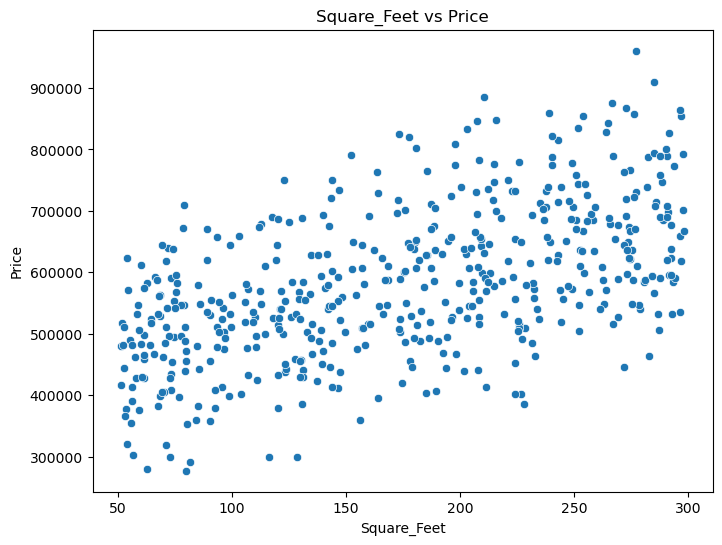

In [54]:
# Task 2.2: Visualise the relationship between Square Feet and Price using a scatter plot.

import seaborn as sns
import matplotlib.pyplot as plt

# Scatter plot between Square feet and Price
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Square_Feet', y='Price', data=df_house_price)
plt.title('Square_Feet vs Price')
plt.xlabel('Square_Feet')
plt.ylabel('Price')
plt.show()


**Task 2.2 here we are creating a scatter plot to visualize the relationship between the houses square feet and the price. Each dot represents a house showing how price changes with the size**


1. The scattered plot above shows that as Square feet increases, price also tends to increase.
2. But we also notice a lot of spread, which means that square feet affects price but not perfectly. 
3. Square feet clearly influences the price but not just on its own, the price is also influenced by other factors like number of bedrooms, locations e.t.c.

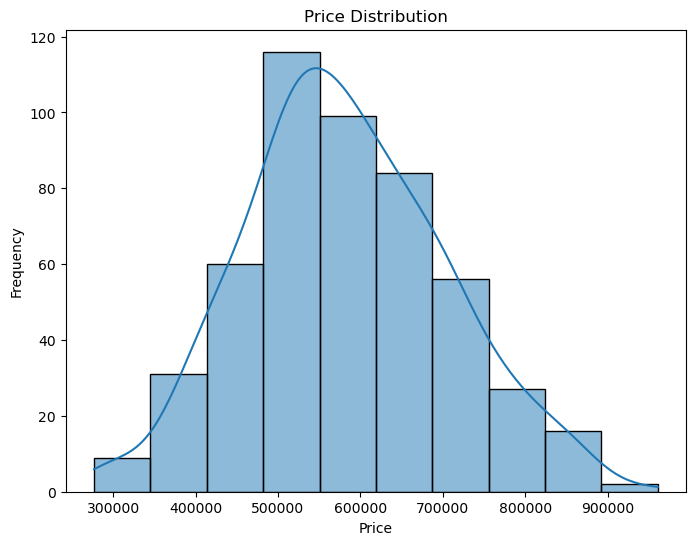

In [55]:
# Task 2.3: Visualise the distribution of the Price variable using a histogram.

plt.figure(figsize=(8, 6))
sns.histplot(df_house_price['Price'], bins=10, kde=True)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

**Task 2.3 this code is creating a histogram to show how house prices are distributed. It is showing how many houses fall into different price ranges**

The histogram above shows that most of the houses are priced around 500000-600000, which is why the bars are highest in the center.

In [56]:
# Task 2.4: Compute and visualize the correlation matrix between the features.

# Select only numeric columns for correlation
numeric_df_house_price = df_house_price.select_dtypes(include=['float64', 'int64'])

# Calculate the correlation matrix
correlation_matrix = numeric_df_house_price.corr()

correlation_matrix

,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Garage_Size,Location_Score,Distance_to_Center,Price
Square_Feet,1.000000,-0.049918,-0.001667,0.056873,-0.051598,-0.035270,0.093080,0.558604
Num_Bedrooms,-0.049918,1.000000,-0.056808,0.009088,-0.065481,-0.000357,0.040511,0.563973
Num_Bathrooms,-0.001667,-0.056808,1.000000,-0.040895,0.055707,-0.013855,-0.082571,0.156689
Num_Floors,0.056873,0.009088,-0.040895,1.000000,-0.082763,0.019928,0.035164,0.177435
Garage_Size,-0.051598,-0.065481,0.055707,-0.082763,1.000000,-0.029939,-0.061407,0.032100
Location_Score,-0.035270,-0.000357,-0.013855,0.019928,-0.029939,1.000000,0.054446,0.071326
Distance_to_Center,0.093080,0.040511,-0.082571,0.035164,-0.061407,0.054446,1.000000,0.000730
Price,0.558604,0.563973,0.156689,0.177435,0.032100,0.071326,0.000730,1.000000


**Task 2.4 This code shows how the numeric features are related to each other and whether they increase or decrease together**

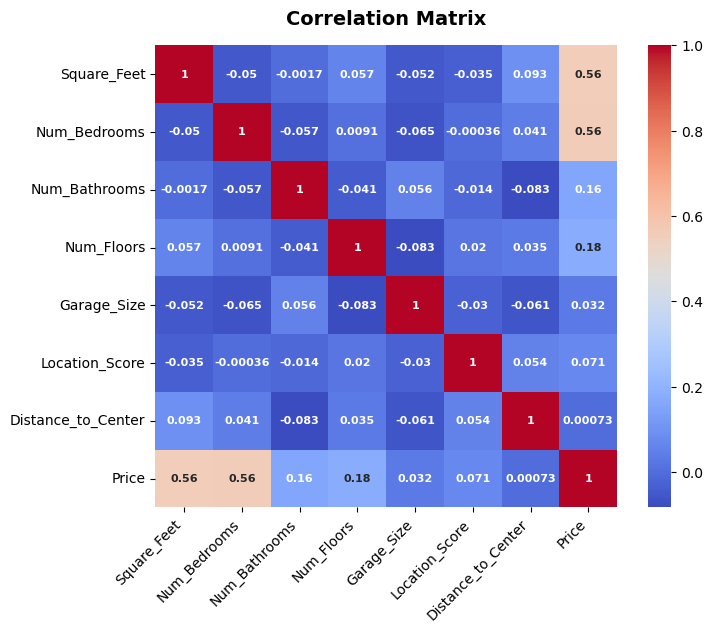

In [57]:
# Task 2.4: Heatmap of correlations using seaborn (NOTE: Color can be changed it it is too bright)
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=True, square=True,
                annot_kws={'fontsize':8, 'fontweight':'bold' })
# Labels and title
plt.title('Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

**Task 2.4 This code produces us a heatmap that shows the correlation between the numeric features, using colors to make strong and weak relationships easy to see. Our heatmap is showing us that the square_feet and Num_bedrooms are the dominant price drivers**

## Step 3: Creating a Multiple Linear Regression (MLR) Model

In this step, we will use Multiple Linear Regression to predict the Price of the house based on the features. We will split the data into a training set and a testing set, fit the model, and evaluate its performance.

Task 3.1: Split the Data into Features and Target
Split the dataset into features (X) and target variable (y).

Task 3.2: Split the Data into Training and Testing Sets
Split the data into training (80%) and testing (20%) sets.

Task 3.3: Train the Multiple Linear Regression Model
Train the Multiple Linear Regression (MLR) model using the training data.

Task 3.4: Visualise the Predicted vs Actual Prices
Create a scatter plot comparing the actual prices and predicted prices for the test set.

Task 3.5: Evaluate the Model
Evaluate the model using Root Mean Squared Error (RMSE) and interpret the results.

In [58]:
# Task 3.1: Split the dataset into features (X) and target variable (y)
X = df_house_price[['Square_Feet', 'Num_Bedrooms', 'Num_Bathrooms', 'Num_Floors', 'Garage_Size', 'Location_Score', 'Distance_to_Center']]
y = df_house_price['Price']

**Task 3.1 this code is splitting our data into features (X) and target variable (y)**

In [59]:
# Task 3.2: Split the data into training (80%) and testing (20%) sets
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the split data
print(f"Training Data: {X_train.shape}, Testing Data: {X_test.shape}")

Training Data: (400, 7), Testing Data: (100, 7)


**Task 3.2 This code is splitting our data into training and testing sets, we are using 80% of the data to train the model and 20% to test how well the model performs. Our data has been split into 400 rows for training and 100 rows for testing with 7 features in each set**

In [60]:
# Task 3.3: Train the Multiple Linear Regression (MLR) model using the training data.
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
model_lr = LinearRegression()

# Fit the model on the training data
model_lr.fit(X_train, y_train)

# Make predictions on the test data
y_pred_lr = model_lr.predict(X_test)

🏃 View run bold_gold_7d9f2cfs at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/f02da96d-81c9-449d-9bc6-9a55033e8f06/#/experiments/ec8fe064-21a9-4da1-b974-d3fb17a5fd78/runs/1fcd6426-5951-46a2-8dd5-98732cc547f1
🧪 View experiment at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/f02da96d-81c9-449d-9bc6-9a55033e8f06/#/experiments/ec8fe064-21a9-4da1-b974-d3fb17a5fd78


**Task 3.3 This code we are using Multiple Linear Regression to train our model**

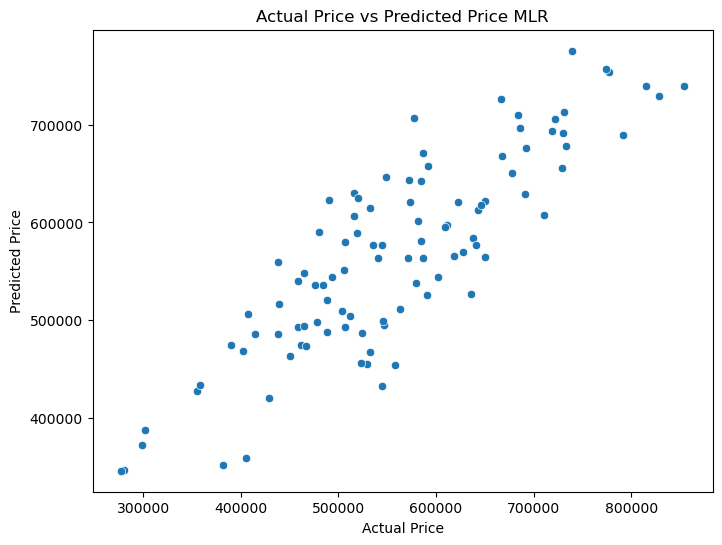

     Actual Price  Predicted Price (MLR)
361   591058.7089          525669.926934
73    667693.0003          668141.051861
374   532377.5802          467168.904743
155   478489.2990          498375.548472
104   730197.4806          691359.973840
..            ...                    ...
347   464849.9178          493645.118779
86    572360.6499          643248.170875
75    557752.8374          454235.083741
438   649930.0523          564489.566281
15    523527.9747          456453.859955

[100 rows x 2 columns]


In [61]:
# Task 3.4 Visualise the Predicted vs Actual Price

# Create dataframe to compare actual vs predicted prices
results_df_mlr = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price (MLR)': y_pred_lr
})

# Create a scatter plot comparing the actual prices and predicted prices for the test set.

import seaborn as sns
import matplotlib.pyplot as plt

# Scatter plot between Actual price and Predicted Price
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Actual Price', y='Predicted Price (MLR)', data=results_df_mlr)
plt.title('Actual Price vs Predicted Price MLR')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.show()

# Display the table
print(results_df_mlr)  # Shows the first few and last few rows of the table

**Task 3.4 This code is comparing the predicted house prices from the MLR model with the actual prices. By visualizing with a scatter plot and a table we can see how accurate the predictions are. We can see that some predictions are close while others are not**

In [62]:
# Task 3.5: Evaluate the model using Root Mean Squared Error (RMSE) and interpret the results.
from sklearn.metrics import mean_squared_error
import numpy as np
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print(f"Root Mean Squared Error (RMSE) for MLR: {rmse_lr}")

Root Mean Squared Error (RMSE) for MLR: 63952.37599755184


**Task 3.5 This code we are calculating the Root Mean Squared Errot (RMSE) to measure how far the predicted prices are from the actual prices on average. A lower RMSE means the models predictons are closer to the actual price**
1. The model shows a strong positive relationship between actual and predicted house prices. As actual prices increase, the predicted prices also increase in a similar pattern.
2. The scatter plot shows most points closely following an upward diagonal, meaning the model's predictions are generally accurate.
3. There is some spread around the line, especially at higher prices, indicating small to moderate prediction errors.
4. The RMSE is approximately 63,952, which means the model's predicted house prices are around $64K from the actual prices. This is reasonable depending on the price range of the houses (300K-800K).

## Step 4: Compare with Random Forest Regressor

Task 4.1: Train a Random Forest Model
Train a Random Forest Regressor model and evaluate its performance.

Task 4.2: Visualise Actual vs Predicted Prices for Random Forest
Create a scatter plot comparing the actual prices and predicted prices for the Random Forest model.

Task 4.3: Model Comparison
Compare the RMSE values of both the MLR and Random Forest models. Which model performs better?

In [63]:
# Task 4.1: Train a Random Forest Regressor model and evaluate its performance

from sklearn.ensemble import RandomForestRegressor
 
# Initialize the Random Forest model
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
 
# Fit the Random Forest model on the training data
model_rf.fit(X_train, y_train)
 
# Make predictions on the test data
y_pred_rf = model_rf.predict(X_test)

🏃 View run zen_pin_3hlxwsk4 at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/f02da96d-81c9-449d-9bc6-9a55033e8f06/#/experiments/ec8fe064-21a9-4da1-b974-d3fb17a5fd78/runs/909aa780-8368-49e6-b2ec-452c363655b3
🧪 View experiment at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/f02da96d-81c9-449d-9bc6-9a55033e8f06/#/experiments/ec8fe064-21a9-4da1-b974-d3fb17a5fd78


**Task 4.1 This code we are training the model with Random Forest Regressor to predict the house prices for the test data**

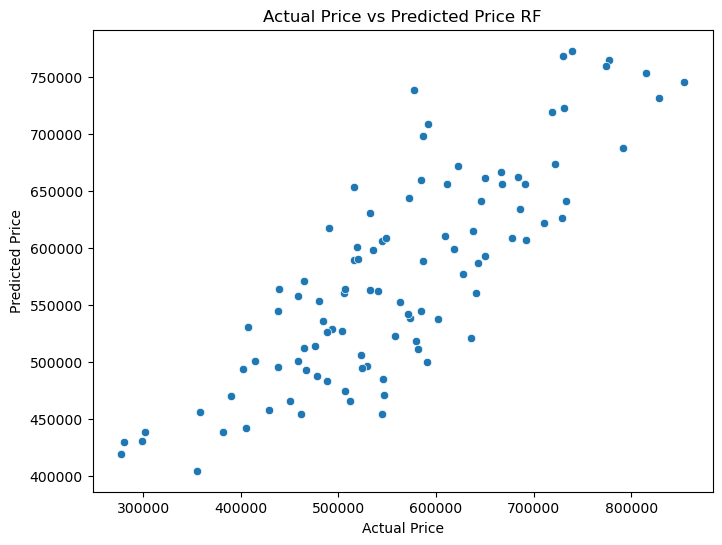

     Actual Price  Predicted Price (Random Forest)
361   591058.7089                    500189.353421
73    667693.0003                    655943.350060
374   532377.5802                    563209.779665
155   478489.2990                    487954.681220
104   730197.4806                    768464.412341
..            ...                              ...
347   464849.9178                    512628.159033
86    572360.6499                    644059.396923
75    557752.8374                    522429.424572
438   649930.0523                    592526.718359
15    523527.9747                    506075.043605

[100 rows x 2 columns]


In [64]:
# Task 4.2: Visualise Actual vs Predicted Prices for Random Forest

# Create a scatter plot comparing the actual prices and predicted prices for the Random Forest model

# Create a DataFrame to compare Actual vs Predicted Prices for Random Forest
results_df_rf = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price (Random Forest)': y_pred_rf
})

# Create a scatter plot comparing the actual prices and predicted prices for the Random Forest test set.

import seaborn as sns
import matplotlib.pyplot as plt

# Scatter plot between Actual price and Predicted Price
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Actual Price', y='Predicted Price (Random Forest)', data=results_df_rf)
plt.title('Actual Price vs Predicted Price RF')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.show()

# Display the table
print(results_df_rf)  # Shows the first few and last few rows of the table

**This code we are comparing the Random Forests predicted house prices with the actual prices. We have created a table and a scatter plot to visualize the predictions. Once again we can see that some predictions are really close while others aren't as close**

In [65]:
# Calculate RMSE for Random Forest
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print(f"Root Mean Squared Error (RMSE) for Random Forest: {rmse_rf}")

Root Mean Squared Error (RMSE) for Random Forest: 71733.35944826744


**The Random Forests models RMSE is indicating the average difference between predicted and actual house prices is approx $71k**

In [66]:
# Task 4.3: Model Comparison 

# Create a DataFrame for Actual vs Predicted prices for both models
results_df = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price (MLR)': y_pred_lr,
    'Predicted Price (Random Forest)': y_pred_rf
})

# Display the table
print(results_df)  # Shows the first few and last few rows of the table

     Actual Price  Predicted Price (MLR)  Predicted Price (Random Forest)
361   591058.7089          525669.926934                    500189.353421
73    667693.0003          668141.051861                    655943.350060
374   532377.5802          467168.904743                    563209.779665
155   478489.2990          498375.548472                    487954.681220
104   730197.4806          691359.973840                    768464.412341
..            ...                    ...                              ...
347   464849.9178          493645.118779                    512628.159033
86    572360.6499          643248.170875                    644059.396923
75    557752.8374          454235.083741                    522429.424572
438   649930.0523          564489.566281                    592526.718359
15    523527.9747          456453.859955                    506075.043605

[100 rows x 3 columns]


**Task 4.3 Here our code can compare actual house prices with the predictions from MLR and Random Forest models to evaluate which model performs better**

In [67]:
# Compare the RMSE of both models
print(f"RMSE for MLR: {rmse_lr}")
print(f"RMSE for Random Forest: {rmse_rf}")

# Provide insights
if rmse_lr < rmse_rf:
    print("The Multiple Linear Regression model performs better based on RMSE.")
else:
    print("The Random Forest model performs better based on RMSE.")

RMSE for MLR: 63952.37599755184
RMSE for Random Forest: 71733.35944826744
The Multiple Linear Regression model performs better based on RMSE.


**Task 4.3 Our code is comparing the RMSE of the MLR and the Random Forest models. We can see that hte RMSE for MLR is about 63,952 and Random Forest is about 71,7333. The lower RMSE indicates the more accurate prediction therefore the MLR model performs better on this dataset**

## Step 5: Conclusion and Insights

Task 5.1: Insights and Recommendations

Based on the RMSE and visualisations, summarise which model performs better and why.

Discuss any improvements that could be made to both models.

#### Insights

•	The Multiple Linear Regression (MLR) model performs better than the Random Forest Regressor based on both RMSE values and visualisations.

•	MLR achieved a lower RMSE of 63,952, compared to 71,733 for Random Forest, indicating more accurate predictions.

•	The scatter plot of predicted vs actual values shows that MLR predictions are closely aligned with the diagonal line, demonstrating strong accuracy and consistency.

•	The better performance of MLR suggests that the relationships between features (e.g., square footage, bedrooms, bathrooms, location score) and house prices are mostly linear.

•	Since MLR is designed for linear relationships, it is well-suited to this dataset.

•	The Random Forest model underperforms because it is designed to capture nonlinear and complex patterns, which are not strongly present in the data.

•	Tuning the Random Forest model (with 200, 400, and 1000 estimators) resulted in only minor improvements, with the best RMSE being 71,291, still worse than MLR.

•	This indicates that increasing model complexity does not significantly enhance performance for this dataset.

•	MLR also provides better interpretability, making it easier to understand how each feature affects house prices.

•	The simpler structure of MLR reduces the risk of overfitting, especially for datasets that are not highly complex.

#### Recommendations

To further improve model performance and reliability, the following steps are recommended:

•	Retain Multiple Linear Regression as the primary model due to its higher accuracy and interpretability

•	Identify and treat outliers to reduce their impact on predictions

•	Continue using visualisations (predicted vs actual plots) to monitor performance

#### Conclusion

The Multiple Linear Regression model is the most suitable choice for this dataset as it provides better accuracy, simpler interpretation, and more reliable predictions for house price estimation.
